# Trade Data Analysis — Fully Explained (pandas + matplotlib)
**Goal:** Provide clean, exam‑ready explanations *before* each code cell, covering what, why, how, expected results, and interpretation.



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1 — Load the dataset safely
**What/Why:** Read the CSV, parse dates, and set the Date as index to enable time-based operations.
**How:** Use `pd.read_csv` and `pd.to_datetime` with the explicit `%d/%m/%Y` format to avoid day/month swap errors.
**Result:** A `DataFrame` `df` indexed by `Date`, sorted chronologically.
**Pitfalls:** If the date format mismatches, parsing may produce NaT; we coerce and drop invalid rows.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/dataset-covid19-trade-impact.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date').set_index('Date')
df.head()

,Direction,Year,Weekday,Country,Commodity,Transport_Mode,Measure,Value,Cumulative
Date,,,,,,,,,
2015-01-01,Exports,2015,Thursday,All,All,All,$,104000000,104000000
2015-01-01,Exports,2015,Thursday,China,"Fish, crustaceans, and molluscs",All,$,0,0
2015-01-01,Exports,2015,Thursday,China,"Logs, wood, and wood articles",All,$,3000000,3000000
2015-01-01,Imports,2015,Thursday,All,Mechanical machinery and equip,All,$,8000000,8000000
2015-01-01,Exports,2015,Thursday,All,Non-food manufactured goods,All,$,16000000,16000000


## Step 2 — Inspect structure and dtypes
**What/Why:** Confirm columns, types, and non‑null counts to plan cleaning and analysis.
**How:** Use `df.info()`.
**Interpretation:** Identify numeric vs. categorical columns and possible casting needs.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 111438 entries, 2015-01-01 to 2021-12-15
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Direction       111438 non-null  object
 1   Year            111438 non-null  int64 
 2   Weekday         111438 non-null  object
 3   Country         111438 non-null  object
 4   Commodity       111438 non-null  object
 5   Transport_Mode  111438 non-null  object
 6   Measure         111438 non-null  object
 7   Value           111438 non-null  int64 
 8   Cumulative      111438 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 8.5+ MB


## Step 3 — Check missing values by column
**What/Why:** Missingness can bias aggregations and charts.
**How:** Use `df.isna().sum()`.
**Interpretation:** Columns with many missing values may need imputation or dropping.

In [6]:
df.isna().sum()

,0
Direction,0
Year,0
Weekday,0
Country,0
Commodity,0
Transport_Mode,0
Measure,0
Value,0
Cumulative,0


## Step 4 — Remove duplicate timestamps
**What/Why:** Duplicate time indices break resampling and rolling windows.
**How:** Keep first occurrence with `~df.index.duplicated()`.
**Result:** Clean, unique Date index.

In [7]:
df = df[~df.index.duplicated(keep='first')]
df.shape

(2541, 9)

## Step 5 — Coerce numeric columns
**What/Why:** Ensure math/plots work correctly even if numbers came as strings.
**How:** `pd.to_numeric(..., errors='coerce')` on `Value` and `Cumulative` if present.
**Result:** Non‑numeric entries become NaN and can be handled consistently.

In [8]:
for col in ['Value','Cumulative']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df[['Value','Cumulative']].head() if set(['Value','Cumulative']).issubset(df.columns) else df.head()

,Value,Cumulative
Date,,
2015-01-01,104000000,104000000
2015-01-02,7000000,12000000
2015-01-03,1000000,2000000
2015-01-04,0,2000
2015-01-05,147000000,271000000


## Step 6 — Descriptive statistics
**What/Why:** Get central tendency and spread to understand scale and variability.
**How:** `df.describe(include='all')`.
**Interpretation:** Look at `mean`, `std`, `min/max`, and unique counts for categoricals.

In [9]:
df.describe(include='all')

,Direction,Year,Weekday,Country,Commodity,Transport_Mode,Measure,Value,Cumulative
count,2541,2541.000000,2541,2541,2541,2541,2541,2.541000e+03,2.541000e+03
unique,3,NaN,7,9,9,3,2,NaN,NaN
top,Exports,NaN,Thursday,All,All,All,$,NaN,NaN
freq,1855,NaN,363,1146,1037,2316,2030,NaN,NaN
mean,NaN,2017.981110,NaN,NaN,NaN,NaN,NaN,2.938863e+07,5.435932e+09
std,NaN,1.992416,NaN,NaN,NaN,NaN,NaN,5.179030e+07,1.009346e+10
min,NaN,2015.000000,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00
25%,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN,1.000000e+06,1.020000e+08
50%,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,8.000000e+06,1.372000e+09
75%,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,2.900000e+07,4.906000e+09


## Step 7 — Daily value trend (time series)
**What/Why:** Visualise how `Value` moves day‑to‑day to spot peaks and dips.
**How:** Simple line chart of `Value` vs. index (Date).
**Interpretation:** Peaks suggest high‑activity days; troughs suggest slow periods.
**Note:** If `Value` is missing, this cell will just inform you.

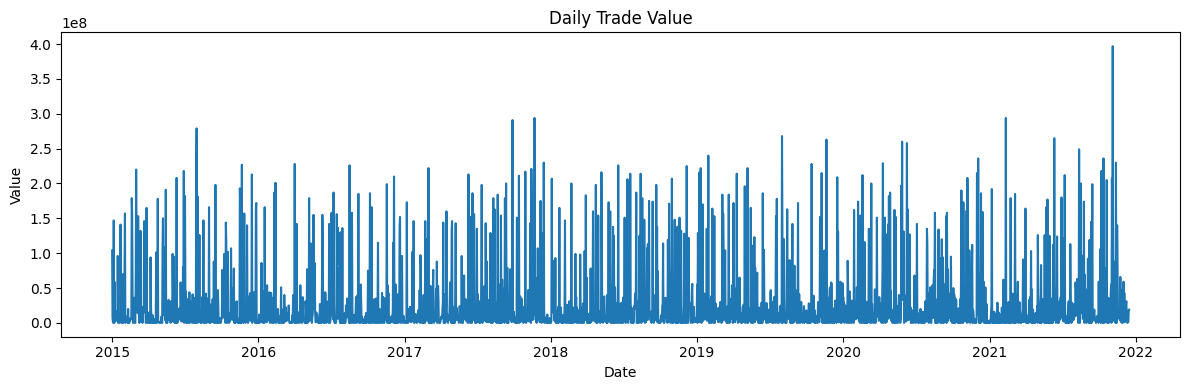

In [10]:
if 'Value' in df.columns:
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df['Value'])
    plt.title('Daily Trade Value')
    plt.xlabel('Date'); plt.ylabel('Value')
    plt.tight_layout(); plt.show()
else:
    print('Column `Value` not available.')

## Step 8 — Cumulative trend check
**What/Why:** Cumulative can show overall growth trajectory.
**How:** Plot `Cumulative` over time if present.
**Interpretation:** Monotonic rise indicates accumulating totals; plateaus/declines need explanation.

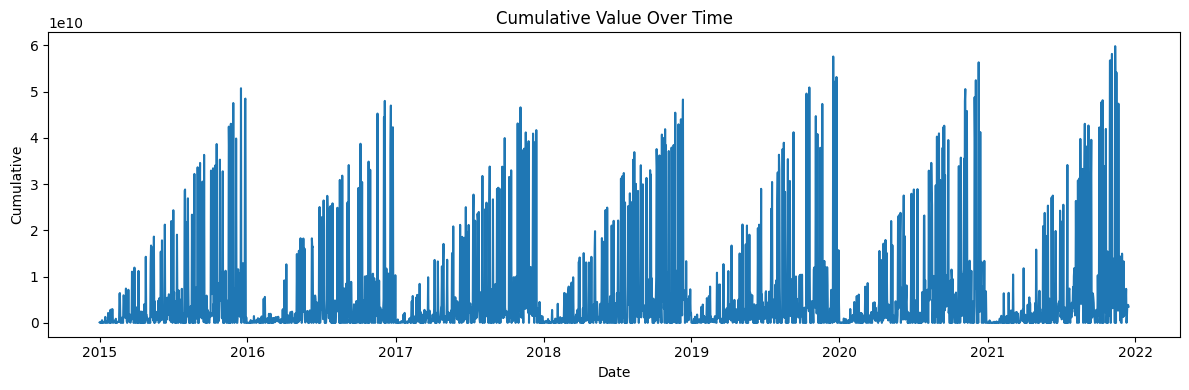

In [11]:
if 'Cumulative' in df.columns:
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df['Cumulative'])
    plt.title('Cumulative Value Over Time')
    plt.xlabel('Date'); plt.ylabel('Cumulative')
    plt.tight_layout(); plt.show()
else:
    print('Column `Cumulative` not available.')

## Step 9 — Weekly seasonality (weekday averages)
**What/Why:** Understand operational weekly rhythm.
**How:** Group by `Weekday` and compute mean `Value`; bar chart.
**Interpretation:** Identify typical busy/slow days.

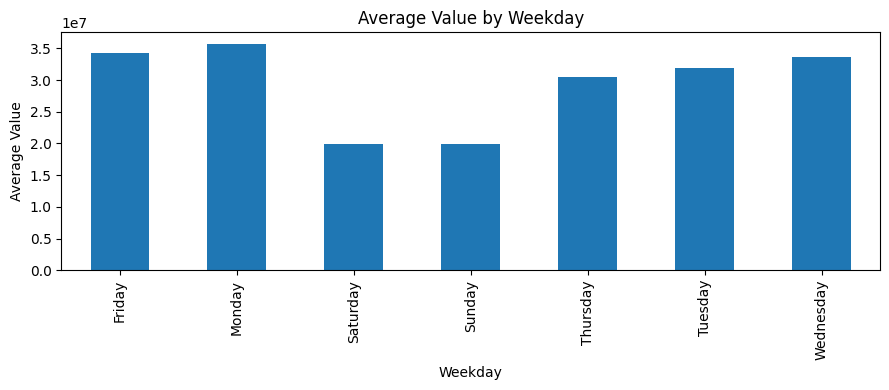

In [12]:
if set(['Weekday','Value']).issubset(df.columns):
    wk = df.groupby('Weekday')['Value'].mean().sort_index()
    wk.plot(kind='bar', figsize=(9,4))
    plt.title('Average Value by Weekday')
    plt.xlabel('Weekday'); plt.ylabel('Average Value')
    plt.tight_layout(); plt.show()
else:
    print('Need columns Weekday and Value.')

## Step 10 — Monthly totals
**What/Why:** Aggregate by calendar month to reveal macro‑patterns.
**How:** `resample('M').sum()` on `Value`.
**Interpretation:** Seasonal spikes/dips across months.

/tmp/ipython-input-4048517336.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_total = df['Value'].resample('M').sum()


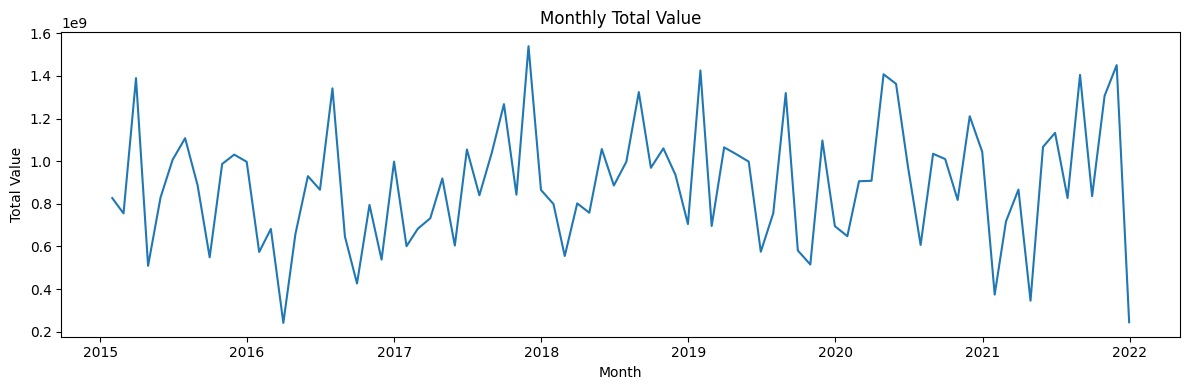

In [13]:
if 'Value' in df.columns:
    monthly_total = df['Value'].resample('M').sum()
    plt.figure(figsize=(12,4))
    plt.plot(monthly_total.index, monthly_total.values)
    plt.title('Monthly Total Value')
    plt.xlabel('Month'); plt.ylabel('Total Value')
    plt.tight_layout(); plt.show()
else:
    print('Column `Value` not available.')

## Step 11 — Monthly averages
**What/Why:** Smooth day-to-day noise; typical monthly level.
**How:** `resample('M').mean()`.
**Interpretation:** Useful for capacity planning and targets.

/tmp/ipython-input-3592663165.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['Value'].resample('M').mean()


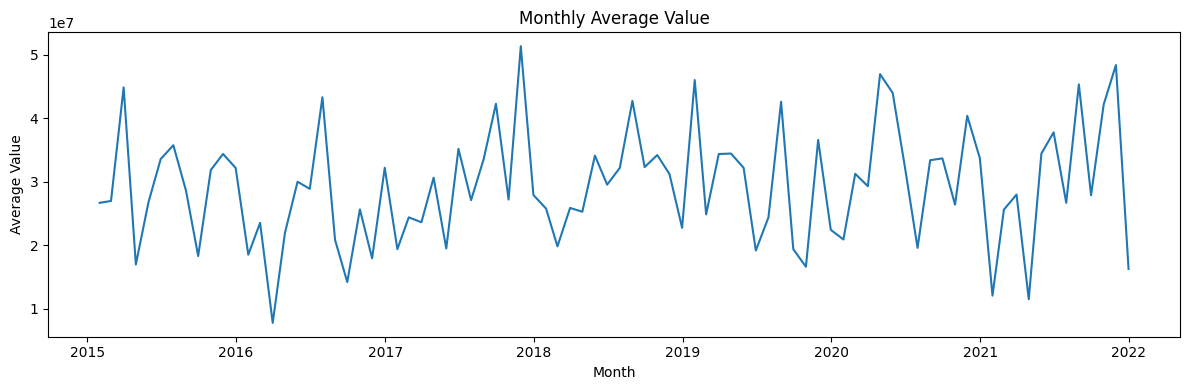

In [14]:
if 'Value' in df.columns:
    monthly_avg = df['Value'].resample('M').mean()
    plt.figure(figsize=(12,4))
    plt.plot(monthly_avg.index, monthly_avg.values)
    plt.title('Monthly Average Value')
    plt.xlabel('Month'); plt.ylabel('Average Value')
    plt.tight_layout(); plt.show()
else:
    print('Column `Value` not available.')

## Step 12 — Yearly totals
**What/Why:** Long‑term growth/decline across years.
**How:** `resample('Y').sum()`.
**Interpretation:** Compare annual performance quickly.

/tmp/ipython-input-1352772632.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df['Value'].resample('Y').sum()


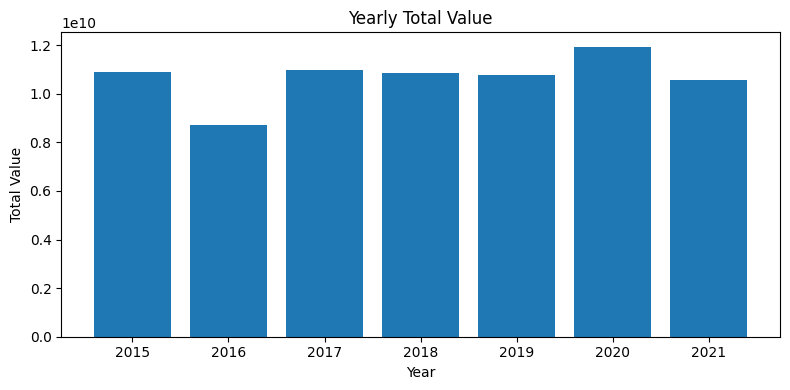

In [15]:
if 'Value' in df.columns:
    yearly = df['Value'].resample('Y').sum()
    plt.figure(figsize=(8,4))
    plt.bar([d.strftime('%Y') for d in yearly.index], yearly.values)
    plt.title('Yearly Total Value')
    plt.xlabel('Year'); plt.ylabel('Total Value')
    plt.tight_layout(); plt.show()
else:
    print('Column `Value` not available.')

## Step 13 — 30‑day rolling mean (trend smoothing)
**What/Why:** Reveal underlying trend by reducing short‑term noise.
**How:** `rolling(30).mean()`.
**Interpretation:** Trend direction (up/down/flat).

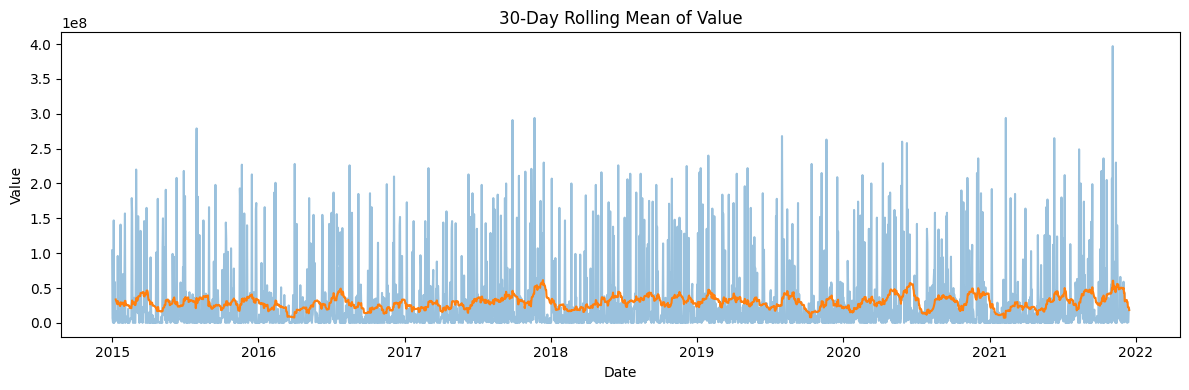

In [16]:
if 'Value' in df.columns:
    roll = df['Value'].rolling(30, min_periods=10).mean()
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df['Value'], alpha=0.45)
    plt.plot(df.index, roll)
    plt.title('30-Day Rolling Mean of Value')
    plt.xlabel('Date'); plt.ylabel('Value')
    plt.tight_layout(); plt.show()
else:
    print('Column `Value` not available.')

## Step 14 — Daily change (1‑day difference)
**What/Why:** Measure volatility and sudden jumps/drops.
**How:** `diff()` on `Value`.
**Interpretation:** Large positive/negative bars indicate shocks.

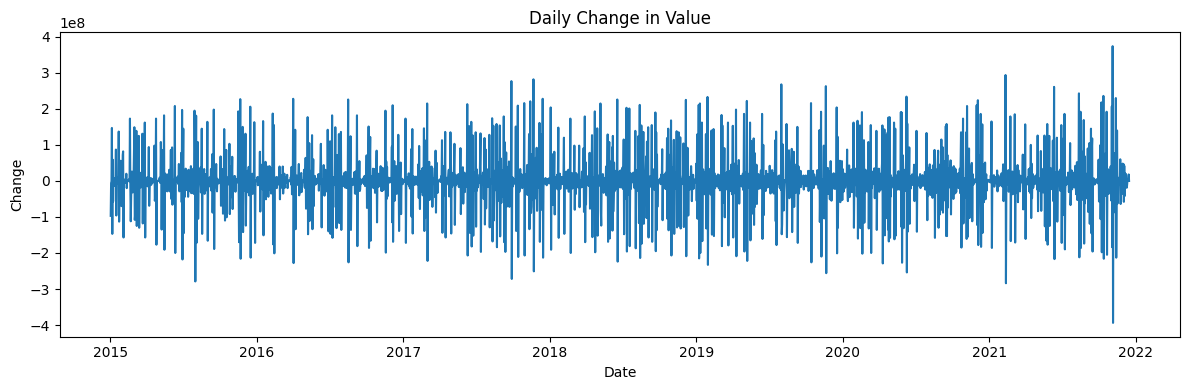

In [17]:
if 'Value' in df.columns:
    df['Daily_Change'] = df['Value'].diff()
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df['Daily_Change'])
    plt.title('Daily Change in Value')
    plt.xlabel('Date'); plt.ylabel('Change')
    plt.tight_layout(); plt.show()
else:
    print('Column `Value` not available.')

## Step 15 — Top & bottom days
**What/Why:** Identify extreme days for root‑cause analysis.
**How:** Use `idxmax/idxmin` and corresponding values.
**Interpretation:** Cross‑check with events/holidays.

In [18]:
if 'Value' in df.columns:
    top_day = df['Value'].idxmax(); top_val = df['Value'].max()
    low_day = df['Value'].idxmin(); low_val = df['Value'].min()
    top_day, int(top_val), low_day, int(low_val)
else:
    print('Column `Value` not available.')

## Step 16 — Commodity contribution
**What/Why:** See which commodities drive totals.
**How:** Group by `Commodity` and sum `Value`; horizontal bar.
**Interpretation:** Focus on top drivers for strategy.

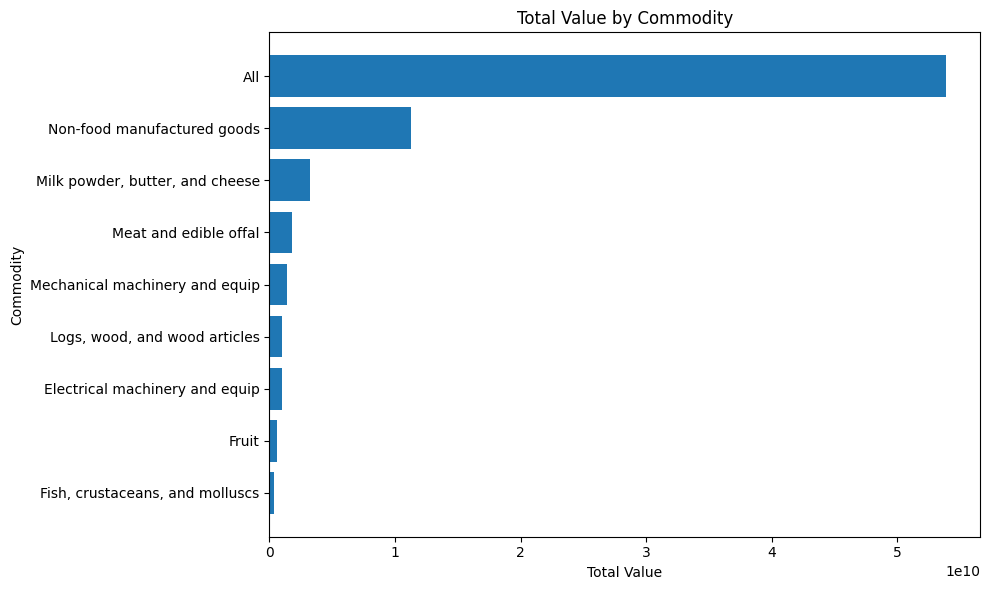

In [19]:
if set(['Commodity','Value']).issubset(df.columns):
    contrib = df.groupby('Commodity')['Value'].sum().sort_values()
    plt.figure(figsize=(10,6))
    plt.barh(contrib.index.astype(str), contrib.values)
    plt.title('Total Value by Commodity')
    plt.xlabel('Total Value'); plt.ylabel('Commodity')
    plt.tight_layout(); plt.show()
else:
    print('Need columns Commodity and Value.')

## Step 17 — Transport mode comparison
**What/Why:** Understand operational dependency on transport modes.
**How:** Group by `Transport_Mode` and sum `Value`; bar chart.
**Interpretation:** Large bars = major logistics channels.

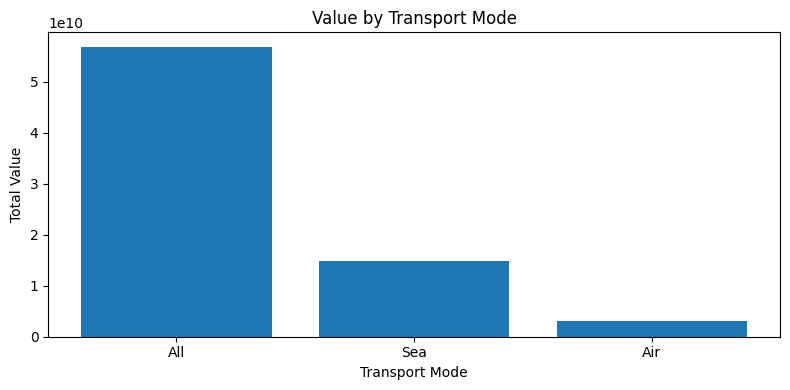

In [20]:
if set(['Transport_Mode','Value']).issubset(df.columns):
    tm = df.groupby('Transport_Mode')['Value'].sum().sort_values(ascending=False)
    plt.figure(figsize=(8,4))
    plt.bar(tm.index.astype(str), tm.values)
    plt.title('Value by Transport Mode')
    plt.xlabel('Transport Mode'); plt.ylabel('Total Value')
    plt.tight_layout(); plt.show()
else:
    print('Need columns Transport_Mode and Value.')

## Step 18 — Direction split (Imports vs Exports)
**What/Why:** Compare trends for each flow direction.
**How:** Split by `Direction`, plot time series for each.
**Interpretation:** Check symmetry or dominance of one direction.

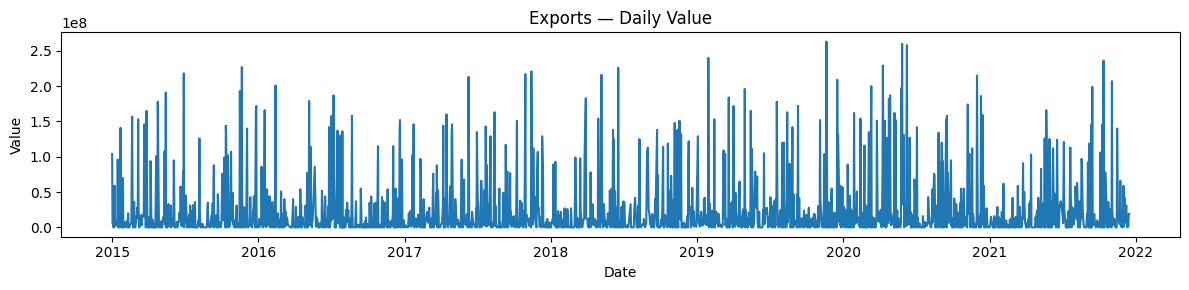

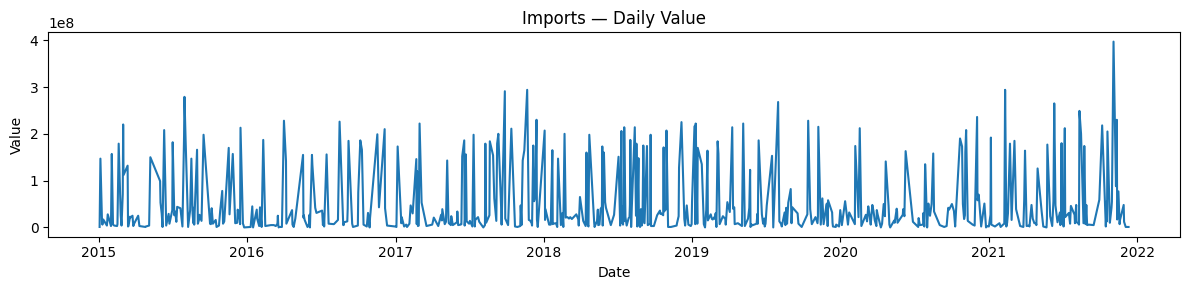

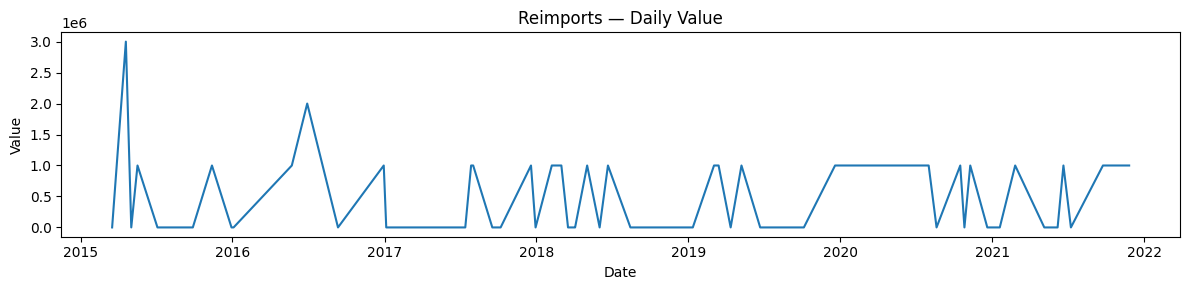

In [21]:
if set(['Direction','Value']).issubset(df.columns):
    for d,g in df.groupby('Direction'):
        plt.figure(figsize=(12,3))
        plt.plot(g.index, g['Value'])
        plt.title(f'{d} — Daily Value')
        plt.xlabel('Date'); plt.ylabel('Value')
        plt.tight_layout(); plt.show()
else:
    print('Need columns Direction and Value.')

## Step 19 — Country contribution
**What/Why:** Identify key geographies.
**How:** Group by `Country` and sum `Value`; horizontal bar.
**Interpretation:** Top countries deserve focus in strategy and risk control.

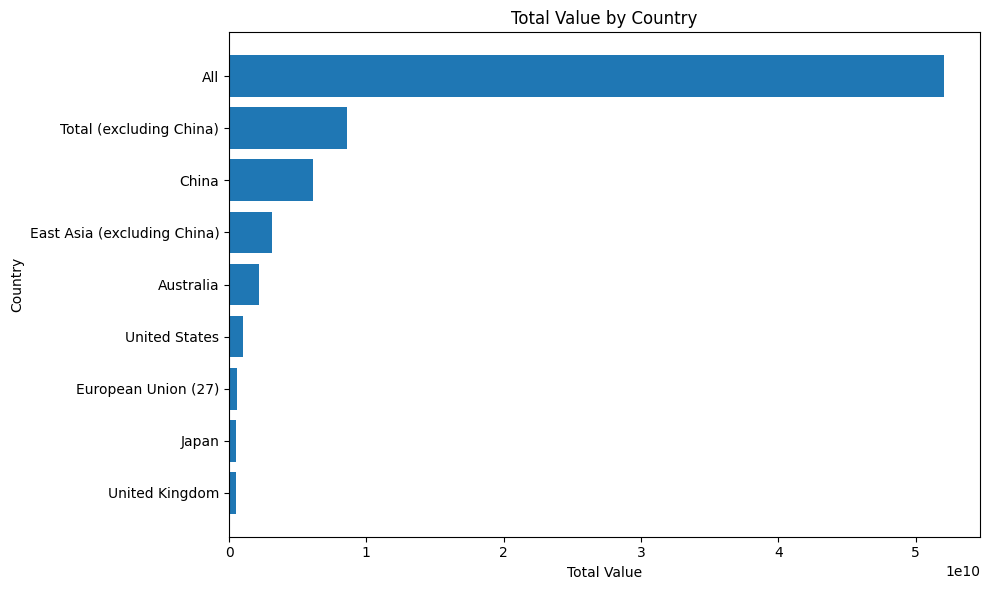

In [22]:
if set(['Country','Value']).issubset(df.columns):
    cc = df.groupby('Country')['Value'].sum().sort_values()
    plt.figure(figsize=(10,6))
    plt.barh(cc.index.astype(str), cc.values)
    plt.title('Total Value by Country')
    plt.xlabel('Total Value'); plt.ylabel('Country')
    plt.tight_layout(); plt.show()
else:
    print('Need columns Country and Value.')

## Step 20 — Simple anomaly tagging (z‑score)
**What/Why:** Flag unusual spikes/dips beyond normal variability.
**How:** Compute z‑score against global mean/std; mark |z|>3.
**Interpretation:** Investigate flagged dates for events or data issues.

In [23]:
import math
if 'Value' in df.columns:
    mean_v = df['Value'].mean(); std_v = df['Value'].std()
    if std_v and std_v > 0:
        z = (df['Value'] - mean_v) / std_v
        anomalies = df[(z.abs() > 3)][['Value']]
        anomalies.head(10)
    else:
        print('Standard deviation is zero; no anomalies by z-score.')
else:
    print('Column `Value` not available.')

## Step 21 — Weekly totals (calendar week)
**What/Why:** Middle‑granularity view between days and months.
**How:** `resample('W').sum()`.
**Interpretation:** Operational cadence and backlog clearing patterns.

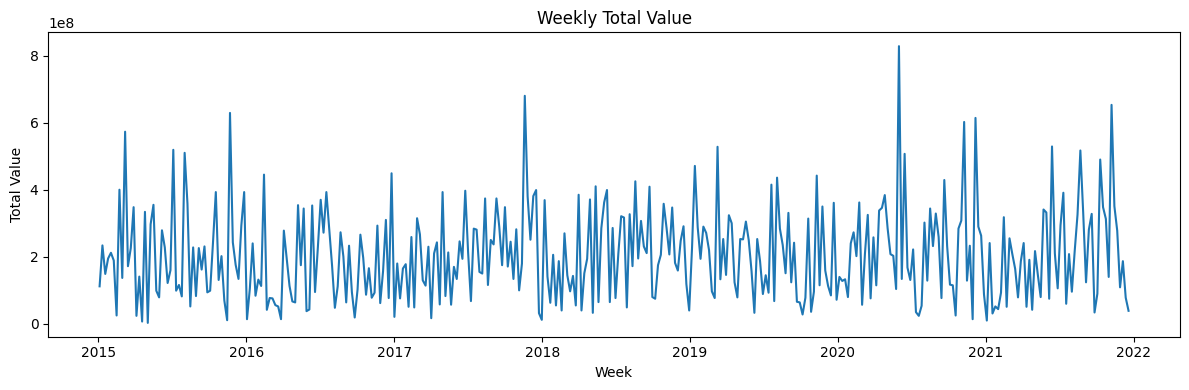

In [24]:
if 'Value' in df.columns:
    weekly = df['Value'].resample('W').sum()
    plt.figure(figsize=(12,4))
    plt.plot(weekly.index, weekly.values)
    plt.title('Weekly Total Value')
    plt.xlabel('Week'); plt.ylabel('Total Value')
    plt.tight_layout(); plt.show()
else:
    print('Column `Value` not available.')

## Step 22 — Rolling volatility (30‑day rolling std)
**What/Why:** Gauge instability of values over time.
**How:** `rolling(30).std()`.
**Interpretation:** Higher std = more volatile periods that may need caution.

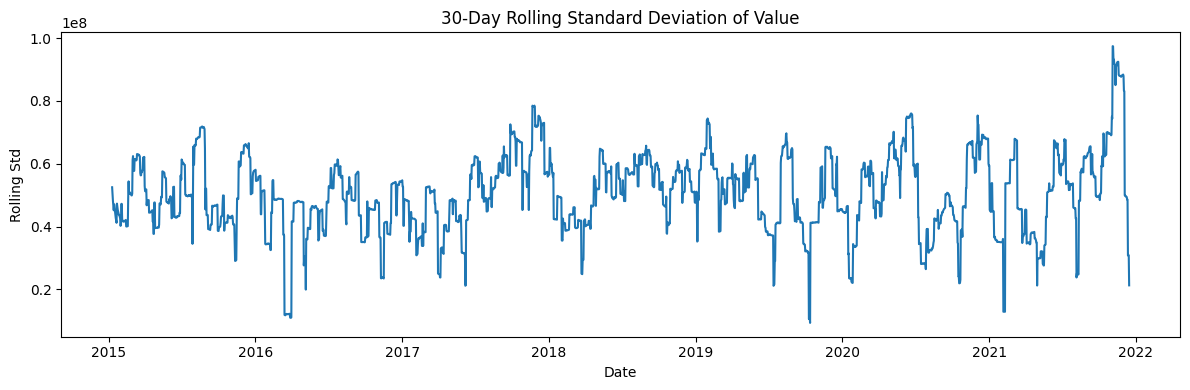

In [25]:
if 'Value' in df.columns:
    rstd = df['Value'].rolling(30, min_periods=10).std()
    plt.figure(figsize=(12,4))
    plt.plot(df.index, rstd)
    plt.title('30-Day Rolling Standard Deviation of Value')
    plt.xlabel('Date'); plt.ylabel('Rolling Std')
    plt.tight_layout(); plt.show()
else:
    print('Column `Value` not available.')

## Step 23 — Weekday vs. Date (small multiples)
**What/Why:** Compare each weekday’s time series to spot recurring patterns.
**How:** Loop over `Weekday` groups and plot lines.
**Interpretation:** Some weekdays may systematically run higher/lower.

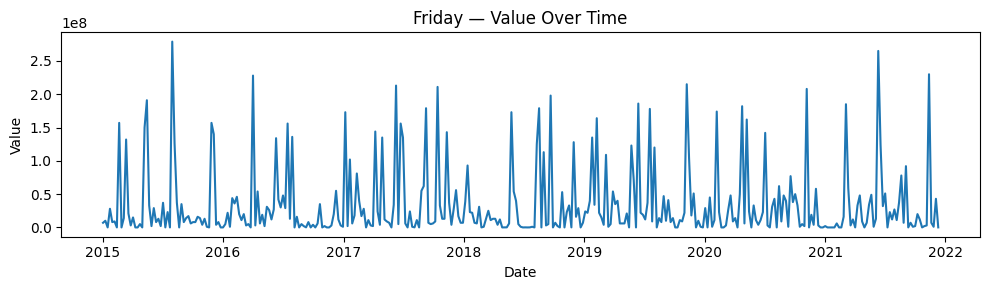

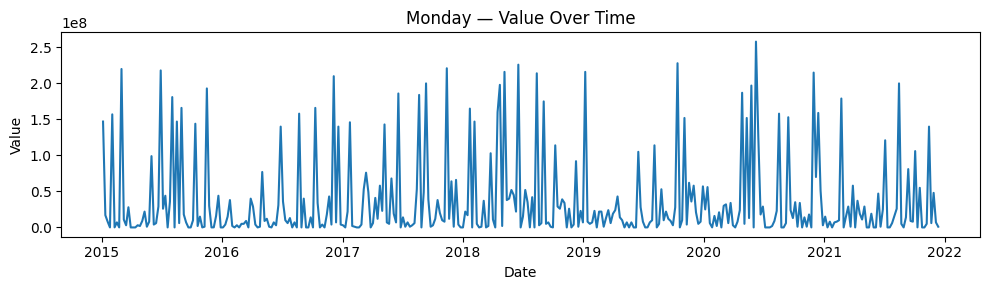

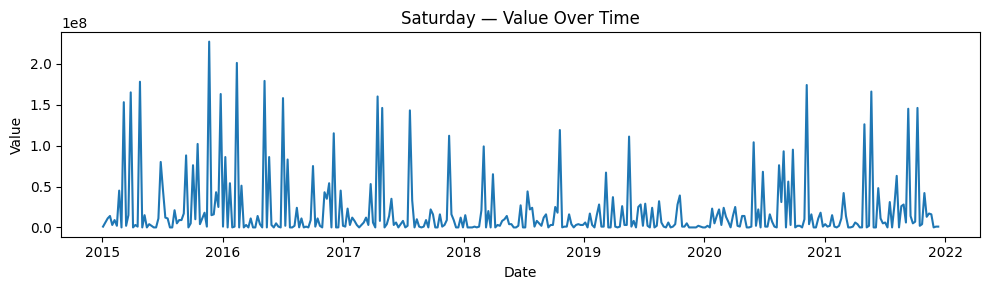

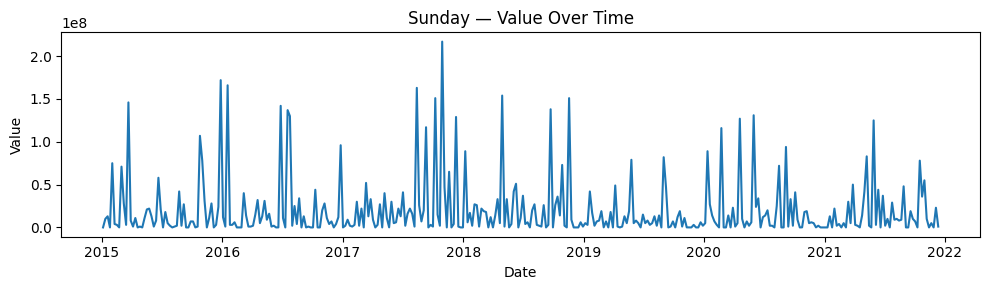

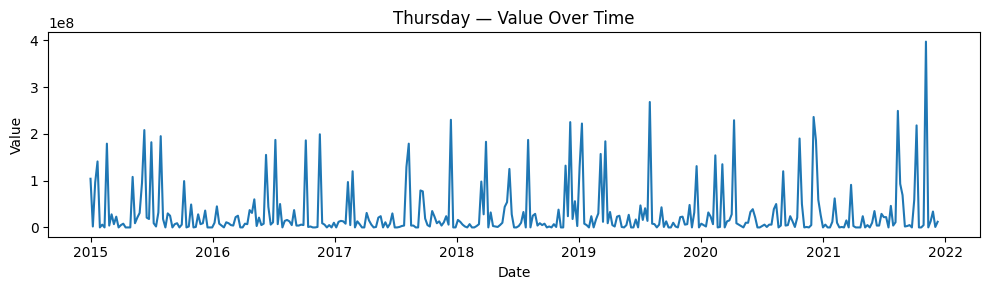

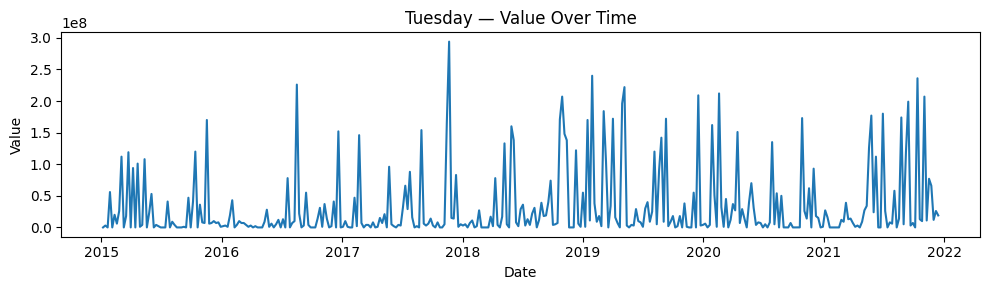

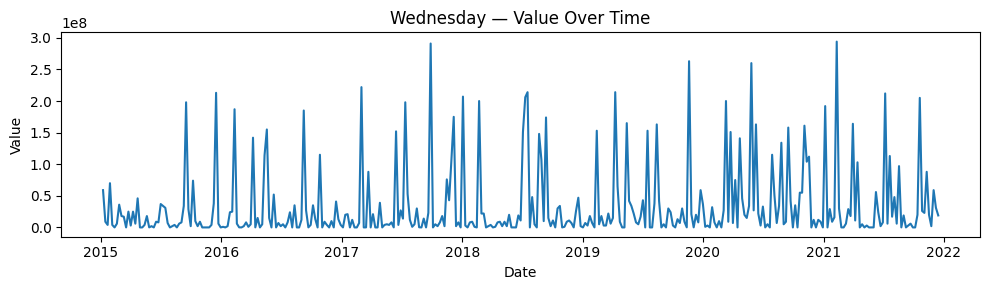

In [26]:
if set(['Weekday','Value']).issubset(df.columns):
    for wd, g in df.groupby('Weekday'):
        plt.figure(figsize=(10,3))
        plt.plot(g.index, g['Value'])
        plt.title(f'{wd} — Value Over Time')
        plt.xlabel('Date'); plt.ylabel('Value')
        plt.tight_layout(); plt.show()
else:
    print('Need columns Weekday and Value.')

## Step 24 — Save cleaned/enhanced dataset
**What/Why:** Preserve your cleaned data and engineered columns for reporting.
**How:** `to_csv` produces a portable file.
**Result:** `clean_trade_detailed.csv` ready for Excel/PPT or further modeling.

In [27]:
df.to_csv('clean_trade_detailed.csv')
'Saved clean_trade_detailed.csv'

'Saved clean_trade_detailed.csv'